# Phase 2: Advanced Data Preprocessing, Feature Engineering & Star Schema Structuring
**Project:** Ford GoBike System Data Analysis  
**Goal:** Clean, transform, encode, and split dataset into relational dimension & fact tables for PostgreSQL integration and interactive Dashboards.

In [10]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')



**Merge The datasets :** there are two files one with the correct date format and the other with misssing columns 

In [11]:
import pandas as pd

df_details = pd.read_csv('fordgobike-tripdataFor201902.csv')
df_dates = pd.read_csv('201902-fordgobike-tripdata.csv')

print("Number of details rows:", len(df_details))
print("Number of dates rows:", len(df_dates))

if len(df_details) == len(df_dates):
    match_rate = (df_details['duration_sec'].values == df_dates['duration_sec'].values).mean()
    print(f"Match rate of duration_sec in order: {match_rate:.4%}")
else:
    print(" Row counts are different  cannot merge directly by position")

Number of details rows: 183416
Number of dates rows: 183412
 Row counts are different  cannot merge directly by position


In [12]:
# 1. Identify all common columns except start_time/end_time
exclude = ['start_time', 'end_time']
common_cols = [c for c in df_details.columns if c in df_dates.columns and c not in exclude]
print("Number of columns used for matching:", len(common_cols))
print(common_cols)

# 2. Most important step: Is this composite key unique within each file individually?
dup_details = df_details.duplicated(subset=common_cols).sum()
dup_dates = df_dates.duplicated(subset=common_cols).sum()
print(f"Duplicate rows in details: {dup_details}")
print(f"Duplicate rows in dates: {dup_dates}")

Number of columns used for matching: 12
['duration_sec', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'bike_share_for_all_trip']
Duplicate rows in details: 14
Duplicate rows in dates: 10


In [14]:
# 3. Merge (inner) — The 4 missing rows will be automatically dropped because they won't find a match
df = pd.merge(
    df_details.drop(columns=['start_time', 'end_time'], errors='ignore'),
    df_dates[common_cols + ['start_time', 'end_time']].drop_duplicates(),
    on=common_cols,
    how='inner'
)

print(f"Number of rows after merge: {len(df)}")
print(f"Difference from original details: {len(df_details) - len(df)}")

Number of rows after merge: 84368
Difference from original details: 99048


In [15]:
#  cleanup: If the code was executed earlier in the same session, drop the old user_id first
df = df.drop(columns=['user_id'], errors='ignore')

user_combos = df[['member_birth_year', 'member_gender', 'user_type']].drop_duplicates().reset_index(drop=True)
user_combos['user_id'] = range(1, len(user_combos) + 1)
df = df.merge(user_combos, on=['member_birth_year', 'member_gender', 'user_type'], how='left')

In [16]:

for col in common_cols:
    print(f"{col:30s} details: {df_details[col].dtype}   dates: {df_dates[col].dtype}")

duration_sec                   details: int64   dates: int64
start_station_id               details: float64   dates: float64
start_station_name             details: str   dates: str
start_station_latitude         details: float64   dates: float64
start_station_longitude        details: float64   dates: float64
end_station_id                 details: float64   dates: float64
end_station_name               details: str   dates: str
end_station_latitude           details: float64   dates: float64
end_station_longitude          details: float64   dates: float64
bike_id                        details: int64   dates: int64
user_type                      details: str   dates: str
bike_share_for_all_trip        details: str   dates: str


In [17]:
# 2. Compare a sample of actual values for (the most common cause of float matching issues)
print("details:")
print(df_details[['start_station_latitude', 'start_station_longitude']].head(3))
print("\ndates:")
print(df_dates[['start_station_latitude', 'start_station_longitude']].head(3))

details:
   start_station_latitude  start_station_longitude
0               37.789625              -122.400811
1               37.791464              -122.391034
2               37.769305              -122.426826

dates:
   start_station_latitude  start_station_longitude
0               37.789625              -122.400811
1               37.791464              -122.391034
2               37.769305              -122.426826


In [18]:
# Narrower but safer key — integer or string columns only, without any floats subject to rounding
safe_join_cols = [
    'duration_sec',          # int - constant
    'start_station_id',      # id - constant (if not float)
    'end_station_id',
    'bike_id',
    'user_type',              # string
    'bike_share_for_all_trip'
]

dup_details2 = df_details.duplicated(subset=safe_join_cols).sum()
dup_dates2 = df_dates.duplicated(subset=safe_join_cols).sum()
print(f"details duplicates: {dup_details2}, dates duplicates: {dup_dates2}")

df_test = pd.merge(
    df_details.drop(columns=['start_time', 'end_time'], errors='ignore'),
    df_dates[safe_join_cols + ['start_time', 'end_time']].drop_duplicates(),
    on=safe_join_cols,
    how='inner'
)
print(f"Number of rows after merge: {len(df_test)}")

details duplicates: 15, dates duplicates: 11
Number of rows after merge: 183438


In [19]:
# Exclude all rows whose key is duplicated in either file (we cannot reliably distinguish between them)
df_details_unique = df_details[~df_details.duplicated(subset=safe_join_cols, keep=False)]
df_dates_unique = df_dates[~df_dates.duplicated(subset=safe_join_cols, keep=False)]

df = pd.merge(
    df_details_unique.drop(columns=['start_time', 'end_time'], errors='ignore'),
    df_dates_unique[safe_join_cols + ['start_time', 'end_time']],
    on=safe_join_cols,
    how='inner'
)

print(f"Number of rows after final merge: {len(df)}")
print(f"Rows excluded due to duplicate keys (accuracy cannot be guaranteed): {len(df_details) - len(df)}")

# Final verification: Are the dates normally distributed now?
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
print(df['start_time'].dt.day_name().value_counts())

Number of rows after final merge: 183386
Rows excluded due to duplicate keys (accuracy cannot be guaranteed): 30
start_time
Thursday     35191
Tuesday      31807
Wednesday    29639
Friday       28974
Monday       26849
Sunday       15521
Saturday     15405
Name: count, dtype: int64


In [20]:
print("Data Shape:", df.shape)
df.info()

Data Shape: (183386, 16)
<class 'pandas.DataFrame'>
RangeIndex: 183386 entries, 0 to 183385
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             183386 non-null  int64         
 1   start_station_id         183193 non-null  float64       
 2   start_station_name       183193 non-null  str           
 3   start_station_latitude   183386 non-null  float64       
 4   start_station_longitude  183386 non-null  float64       
 5   end_station_id           183193 non-null  float64       
 6   end_station_name         183193 non-null  str           
 7   end_station_latitude     183386 non-null  float64       
 8   end_station_longitude    183386 non-null  float64       
 9   bike_id                  183386 non-null  int64         
 10  user_type                183386 non-null  str           
 11  member_birth_year        175121 non-null  float64       
 12  me

In [21]:
df.dtypes

duration_sec                        int64
start_station_id                  float64
start_station_name                    str
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_name                      str
end_station_latitude              float64
end_station_longitude             float64
bike_id                             int64
user_type                             str
member_birth_year                 float64
member_gender                         str
bike_share_for_all_trip               str
start_time                 datetime64[us]
end_time                              str
dtype: object

In [22]:
df.head(15)

,duration_sec,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_time,end_time
0,52185,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,2019-02-28 17:32:10.145,2019-03-01 08:01:55.9750
1,42521,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,2019-02-28 18:53:21.789,2019-03-01 06:42:03.0560
2,61854,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,2019-02-28 12:13:13.218,2019-03-01 05:24:08.1460
3,36490,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,2019-02-28 17:54:26.010,2019-03-01 04:02:36.8420
4,1585,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,2019-02-28 23:54:18.549,2019-03-01 00:20:44.0740
5,1793,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,2019-02-28 23:49:58.632,2019-03-01 00:19:51.7600
6,1147,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No,2019-02-28 23:55:35.104,2019-03-01 00:14:42.5880
7,1615,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,2019-02-28 23:41:06.766,2019-03-01 00:08:02.7560
8,1570,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,2019-02-28 23:41:48.790,2019-03-01 00:07:59.7150
9,1049,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No,2019-02-28 23:49:47.699,2019-03-01 00:07:17.0250


In [23]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,start_time
count,183386.000000,183193.000000,183386.000000,183386.000000,183193.000000,183386.000000,183386.000000,183386.000000,175121.000000,183386
mean,726.127480,138.583985,37.771256,-122.352700,136.243770,37.771460,-122.352286,4472.906427,1984.805917,2019-02-15 21:08:53.463358
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000,2019-02-01 00:04:40.616000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000,2019-02-08 08:32:13.823500
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000,2019-02-15 23:08:15.062000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000,2019-02-22 11:01:52.347750
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000,2019-02-28 23:59:18.548000
std,1794.511123,111.775772,0.099515,0.117032,111.512976,0.099423,0.116608,1664.458812,10.116961,NaN


**STEP 1 ( Clean Data ):**  fix missing values, remove outliers, standardize categories. 

In [24]:
# 1. Handling Missing Timestamps & Duplicates
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df = df.dropna(subset=['start_time', 'end_time'])
df = df.drop_duplicates()

# 2. Handling Missing Member Info & Outliers Filter
df = df.dropna(subset=['member_birth_year', 'member_gender'])
df = df[(df['member_birth_year'] >= 1939) & (df['member_birth_year'] <= 2001)]
df = df[df['duration_sec'] <= 86400]

# 3. Data Types Standardization
df['member_birth_year'] = df['member_birth_year'].astype(int)
df['start_station_id'] = df['start_station_id'].astype('Int64')
df['end_station_id'] = df['end_station_id'].astype('Int64')
df['bike_id'] = df['bike_id'].astype(str)

df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')

# 4. Verify Final Cleaned Dataset Info
print(f"Remaining Clean Rows: {len(df)}")
df.info()

Remaining Clean Rows: 174929
<class 'pandas.DataFrame'>
Index: 174929 entries, 0 to 183385
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174929 non-null  int64         
 1   start_station_id         174738 non-null  Int64         
 2   start_station_name       174738 non-null  str           
 3   start_station_latitude   174929 non-null  float64       
 4   start_station_longitude  174929 non-null  float64       
 5   end_station_id           174738 non-null  Int64         
 6   end_station_name         174738 non-null  str           
 7   end_station_latitude     174929 non-null  float64       
 8   end_station_longitude    174929 non-null  float64       
 9   bike_id                  174929 non-null  str           
 10  user_type                174929 non-null  category      
 11  member_birth_year        174929 non-null  int64         
 12  mem

**STEP 2 : (Feature Engineering )**:   trip duration in minutes, weekend flag, age groups.

In [25]:
df['duration_min'] = (df['duration_sec'] / 60).round(2)
df['duration_hours'] = (df['duration_sec'] / 3600).round(2)
df['weekend_flag'] = df['start_time'].dt.dayofweek.isin([5, 6]).astype(int)

age_bins = [17, 25, 35, 50, 65, 80]
age_labels = ['18-25', '26-35', '36-50', '51-65', '66-80']

df['start_date'] = df['start_time'].dt.date
df['start_hour'] = df['start_time'].dt.hour
df['start_day'] = df['start_time'].dt.day
df['start_day_of_week'] = df['start_time'].dt.day_name()
df['start_day_name'] = df['start_day_of_week']
df['start_month'] = df['start_time'].dt.month
df['start_year'] = df['start_time'].dt.year
df['member_age'] = 2019 - df['member_birth_year']
df['age_group'] = pd.cut(df['member_age'], bins=age_bins, labels=age_labels)

In [27]:
#Star Schema
df = df.dropna(subset=['start_station_id', 'end_station_id'])  

df['trip_id'] = range(1, len(df) + 1)

user_combos = df[['member_birth_year', 'member_gender', 'user_type']].drop_duplicates().reset_index(drop=True)
user_combos['user_id'] = range(1, len(user_combos) + 1)
df = df.merge(user_combos, on=['member_birth_year', 'member_gender', 'user_type'], how='left')

df['time_id'] = df['start_time'].dt.strftime('%Y%m%d%H%M').astype(int)
df.tail(35)


,duration_sec,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,...,start_day_of_week,start_day_name,start_month,start_year,member_age,age_group,trip_id,user_id_x,time_id,user_id_y
174703,612,240,Haste St at Telegraph Ave,37.866043,-122.258804,241,Ashby BART Station,37.852477,-122.270213,414,...,Friday,Friday,2,2019,37,36-50,174704,42,201902010103,42
174704,1409,230,14th St at Mandela Pkwy,37.810743,-122.291415,150,Adeline St at 40th St,37.831277,-122.278267,3615,...,Friday,Friday,2,2019,30,26-35,174705,7,201902010047,7
174705,954,11,Davis St at Jackson St,37.797280,-122.398436,44,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,545,...,Friday,Friday,2,2019,45,36-50,174706,4,201902010054,4
174706,258,316,San Salvador St at 1st St,37.330165,-121.885831,297,Locust St at Grant St,37.322980,-121.887931,3778,...,Friday,Friday,2,2019,43,36-50,174707,66,201902010103,66
174707,151,19,Post St at Kearny St,37.788975,-122.403452,324,Union Square (Powell St at Post St),37.788300,-122.408531,4832,...,Friday,Friday,2,2019,35,26-35,174708,19,201902010104,19
174708,728,368,Myrtle St at Polk St,37.785434,-122.419622,91,Berry St at King St,37.771762,-122.398438,4974,...,Friday,Friday,2,2019,29,26-35,174709,16,201902010054,16
174709,718,368,Myrtle St at Polk St,37.785434,-122.419622,91,Berry St at King St,37.771762,-122.398438,5045,...,Friday,Friday,2,2019,28,26-35,174710,20,201902010054,20
174710,659,47,4th St at Harrison St,37.780955,-122.399749,67,San Francisco Caltrain Station 2 (Townsend St...,37.776639,-122.395526,4960,...,Friday,Friday,2,2019,34,26-35,174711,82,201902010053,82
174711,417,80,Townsend St at 5th St,37.775235,-122.397437,126,Esprit Park,37.761634,-122.390648,5223,...,Friday,Friday,2,2019,28,26-35,174712,52,201902010053,52
174712,943,31,Raymond Kimbell Playground,37.783813,-122.434559,31,Raymond Kimbell Playground,37.783813,-122.434559,5343,...,Friday,Friday,2,2019,47,36-50,174713,35,201902010043,35


**STEP 3 : (Encoding  Scaling )**:  convert categorical to numeric, scale numbers if needed. 

In [ ]:
# 1. Label Encoding Categoricals
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler

# Binary Encoding
if 'bike_share_for_all_trip' in df.columns:
    df['bike_share_encoded'] = df['bike_share_for_all_trip'].map({'Yes': 1, 'No': 0})

# Nominal Categoricals (Label Encoding)
le_user = LabelEncoder()
le_gender = LabelEncoder()

df['user_type_encoded'] = le_user.fit_transform(df['user_type'])
df['gender_encoded'] = le_gender.fit_transform(df['member_gender'])

# Ordinal Encoding for Age Groups
age_mapping = {'18-25': 0, '26-35': 1, '36-50': 2, '51-65': 3, '66-80': 4}
if 'age_group' in df.columns:
    df['age_group_encoded'] = df['age_group'].map(age_mapping)

# Ordinal Encoding for Day of Week (Preserving natural order: Mon=0 -> Sun=6)
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
if 'start_day_of_week' in df.columns:
    df['day_of_week_encoded'] = df['start_day_of_week'].map(day_mapping)

In [29]:
#Feature Scaling


# Standard Scaler for Age
scaler_std = StandardScaler()
df['age_scaled'] = scaler_std.fit_transform(df[['member_age']])

# Robust Scaler for Duration (Handles extreme values/outliers much better)
scaler_robust = RobustScaler()
df['duration_min_scaled'] = scaler_robust.fit_transform(df[['duration_min']])

In [30]:
# Test The encoding 
encoded_columns = [
    'user_type', 'user_type_encoded', 
    'member_gender', 'gender_encoded',
    'bike_share_for_all_trip', 'bike_share_encoded',
    'age_group', 'age_group_encoded',
    'start_day_of_week', 'day_of_week_encoded',
    'member_age', 'age_scaled',
    'duration_min', 'duration_min_scaled'
]

available_cols = [col for col in encoded_columns if col in df.columns]
display(df[available_cols].head())

,user_type,user_type_encoded,member_gender,gender_encoded,bike_share_for_all_trip,bike_share_encoded,age_group,age_group_encoded,start_day_of_week,day_of_week_encoded,member_age,age_scaled,duration_min,duration_min_scaled
0,Customer,0,Male,1,No,0,26-35,1,Thursday,3,35,0.088513,869.75,110.840412
1,Customer,0,Male,1,No,0,36-50,2,Thursday,3,47,1.303352,1030.90,131.580438
2,Subscriber,1,Other,2,No,0,26-35,1,Thursday,3,30,-0.417670,608.17,77.175032
3,Subscriber,1,Male,1,Yes,1,36-50,2,Thursday,3,45,1.100878,26.42,2.303732
4,Subscriber,1,Male,1,No,0,51-65,3,Thursday,3,60,2.619427,29.88,2.749035


**STEP 4 : (EDA )**:  trips by weekday, duration distribution, subscriber vs customer.

1 - Trips by weekday

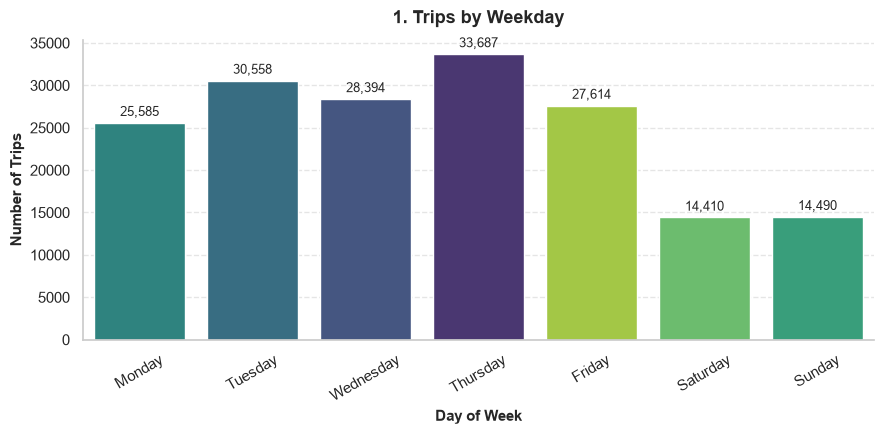

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(9, 4.5), dpi=100)


weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


ax = sns.countplot(
    data=df, 
    x='start_day_name', 
    order=weekday_order, 
    palette='viridis', 
    hue='start_day_name', 
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height):,}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=9, xytext=(0, 3), 
            textcoords='offset points'
        )


plt.title('1. Trips by Weekday', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Day of Week', fontsize=11, fontweight='bold')
plt.ylabel('Number of Trips', fontsize=11, fontweight='bold')


plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Trip Duration Distrubtion

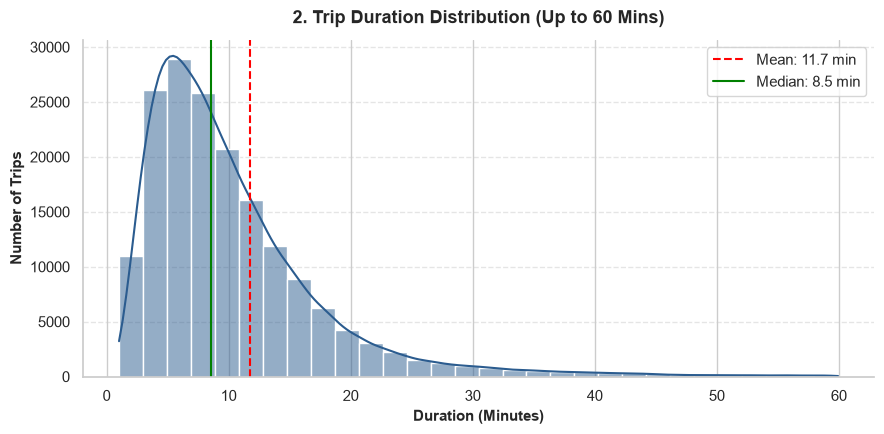

In [32]:
plt.figure(figsize=(9, 4.5), dpi=100)

sns.histplot(
    data=df[df['duration_min'] <= 60], 
    x='duration_min', 
    bins=30, 
    kde=True, 
    color='#2b5c8f'
)


mean_val = df['duration_min'].mean()
median_val = df['duration_min'].median()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f} min')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f} min')

plt.title('2. Trip Duration Distribution (Up to 60 Mins)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Duration (Minutes)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Trips', fontsize=11, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

Trip Duration By user Type

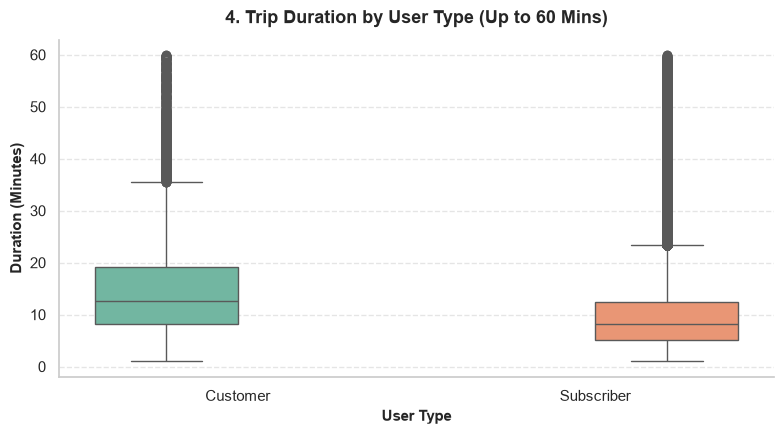

In [33]:
plt.figure(figsize=(8, 4.5), dpi=100)

sns.boxplot(
    data=df[df['duration_min'] <= 60], 
    x='user_type', 
    y='duration_min', 
    palette='Set2', 
    hue='user_type', 
    legend=False
)

plt.title('4. Trip Duration by User Type (Up to 60 Mins)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('User Type', fontsize=11, fontweight='bold')
plt.ylabel('Duration (Minutes)', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

 Heatmap: Trips by Hour and Day of Week

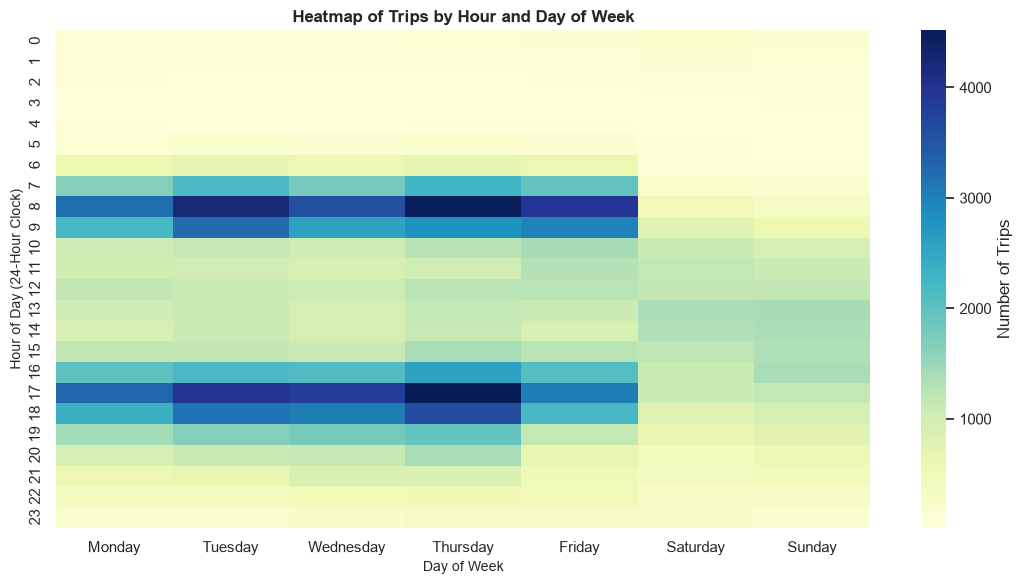

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6), dpi=100)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.groupby(['start_day_of_week', 'start_hour']).size().unstack(level=0)[days_order]

sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Number of Trips'})

plt.title('Heatmap of Trips by Hour and Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week', fontsize=10)
plt.ylabel('Hour of Day (24-Hour Clock)', fontsize=10)
plt.tight_layout()
plt.show()

Trip Volume by Day Split by User Type

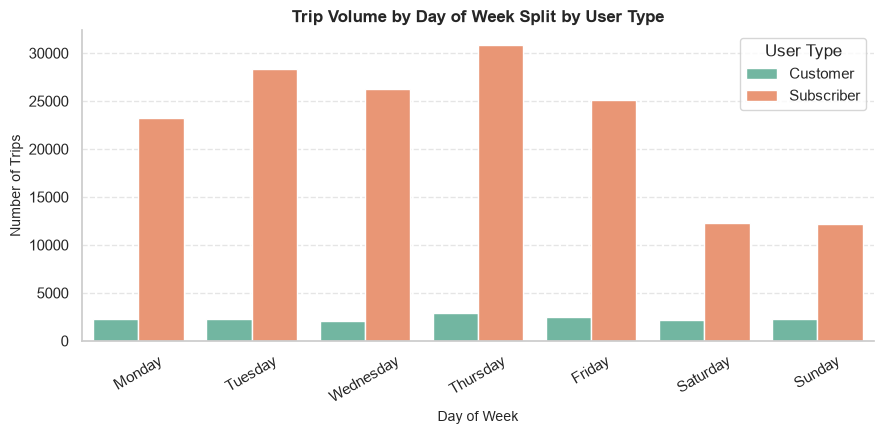

In [35]:
plt.figure(figsize=(9, 4.5), dpi=100)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(
    data=df,
    x='start_day_of_week',
    hue='user_type',
    order=days_order,
    palette='Set2'
)

plt.title('Trip Volume by Day of Week Split by User Type', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week', fontsize=10)
plt.ylabel('Number of Trips', fontsize=10)
plt.legend(title='User Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Top 10 Start and End Stations

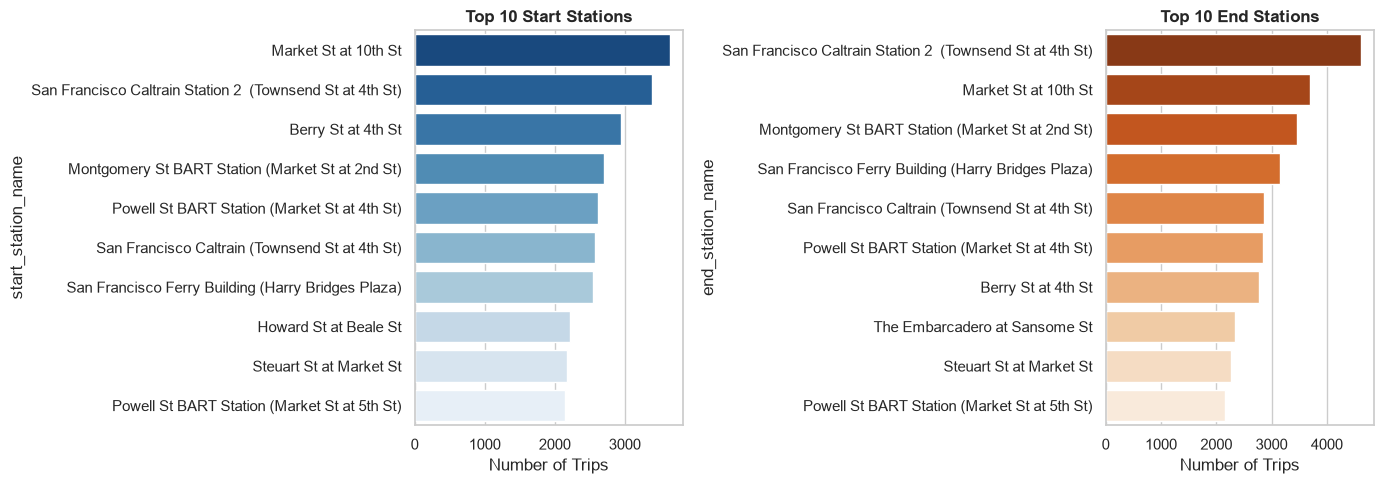

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Top 10 Start Stations
top_start = df['start_station_name'].value_counts().head(10)
sns.barplot(x=top_start.values, y=top_start.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Start Stations', fontweight='bold')
axes[0].set_xlabel('Number of Trips')

# Top 10 End Stations
top_end = df['end_station_name'].value_counts().head(10)
sns.barplot(x=top_end.values, y=top_end.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 End Stations', fontweight='bold')
axes[1].set_xlabel('Number of Trips')

plt.tight_layout()
plt.show()

Gender Distribution

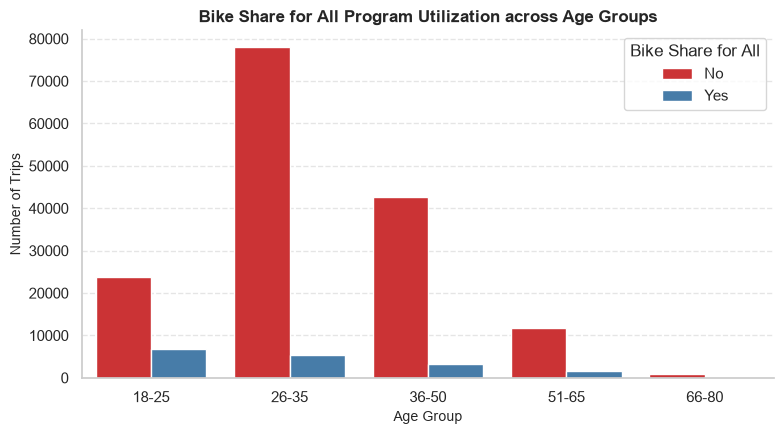

In [37]:
if 'age_group' in df.columns and 'bike_share_for_all_trip' in df.columns:
    plt.figure(figsize=(8, 4.5), dpi=100)

    sns.countplot(
        data=df,
        x='age_group',
        hue='bike_share_for_all_trip',
        palette='Set1'
    )

    plt.title('Bike Share for All Program Utilization across Age Groups', fontsize=12, fontweight='bold')
    plt.xlabel('Age Group', fontsize=10)
    plt.ylabel('Number of Trips', fontsize=10)
    plt.legend(title='Bike Share for All')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine()

    plt.tight_layout()
    plt.show()

 Trip Duration Distribution by User Type

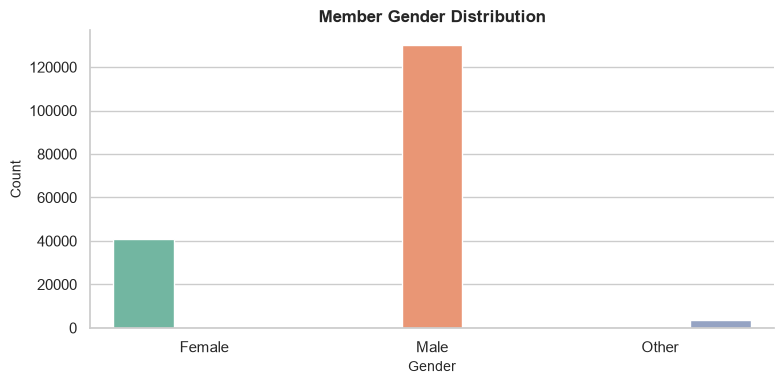

In [39]:
plt.figure(figsize=(8, 4), dpi=100)
ax = sns.countplot(data=df, x='member_gender', palette='Set2', hue='member_gender', legend=False)
plt.title('Member Gender Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Gender', fontsize=10)
plt.ylabel('Count', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

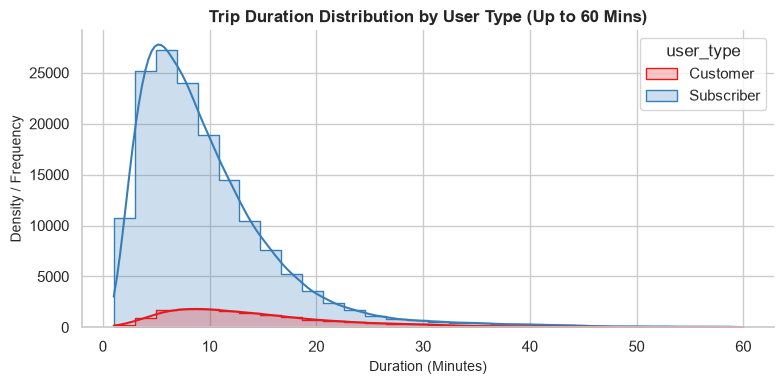

In [41]:
plt.figure(figsize=(8, 4), dpi=100)
sns.histplot(
    data=df[df['duration_min'] <= 60],
    x='duration_min',
    hue='user_type',
    bins=30,
    kde=True,
    element='step',
    common_norm=False,
    palette='Set1'
)
plt.title('Trip Duration Distribution by User Type (Up to 60 Mins)', fontsize=12, fontweight='bold')
plt.xlabel('Duration (Minutes)', fontsize=10)
plt.ylabel('Density / Frequency', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

Data warehouse pipline preparation 

In [ ]:
import numpy as np
import pandas as pd


# 1. Feature Engineering & Preparation for Data warehouseing



df['date'] = df['start_time'].dt.date
df['hour'] = df['start_time'].dt.hour
df['day'] = df['start_time'].dt.day
df['day_of_week'] = df['start_time'].dt.day_name()
df['month'] = df['start_time'].dt.month
df['year'] = df['start_time'].dt.year


df['time_id'] = df['start_time'].dt.strftime('%Y%m%d%H').astype(int)


df['trip_id'] = np.arange(1, len(df) + 1)


df['start_station_id'] = df['start_station_id'].astype('Int64')
df['end_station_id'] = df['end_station_id'].astype('Int64')
df['bike_id'] = df['bike_id'].astype(str)



# 2. Select & Order Final Columns for Export


final_cols = [
    # Fact Attributes
    'trip_id',
    'start_time',
    'end_time',
    'duration_sec',
    'duration_min',
    'bike_id',
    # Station Dimension Inputs
    'start_station_id',
    'start_station_name',
    'start_station_latitude',
    'start_station_longitude',
    'end_station_id',
    'end_station_name',
    'end_station_latitude',
    'end_station_longitude',
    # User Dimension Inputs
    'member_birth_year',
    'member_age',
    'member_gender',
    'user_type',
    # Time Dimension Inputs
    'time_id',
    'date',
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
]

cleaned_df = df[final_cols].copy()


# 3. Export Cleaned Dataset

cleaned_df.to_csv('cleaned_fordgobike_master.csv', index=False)

print(
    'SUCCESS: Prepared dataset exported successfully as'
    ' "cleaned_fordgobike_master.csv"!'
)

SUCCESS: Prepared dataset exported successfully as "cleaned_fordgobike_master.csv"!


In [47]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,member_birth_year,start_time,end_time,...,user_type_encoded,gender_encoded,day_of_week_encoded,age_scaled,duration_min_scaled,user_id,hour,day,month,year
count,174738.000000,174738.0,174738.000000,174738.000000,174738.0,174738.000000,174738.000000,174738.000000,174738,174738,...,174738.000000,174738.000000,174738.000000,1.747380e+05,174738.000000,174738.000000,174738.000000,174738.000000,174738.0,174738.0
mean,704.349329,139.014473,37.771228,-122.351748,136.635655,37.771424,-122.351324,1984.874315,2019-02-15 21:24:42.327046,2019-02-15 21:36:27.175301,...,0.905247,0.787539,2.620226,3.053002e-16,0.414305,50.183744,13.456358,15.310677,2.0,2019.0
min,61.000000,3.0,37.317298,-122.453705,3.0,37.317298,-122.453705,1939.000000,2019-02-01 00:04:40.616000,2019-02-01 00:12:50.034000,...,0.000000,0.000000,0.000000,-1.632509e+00,-0.965251,1.000000,0.000000,1.000000,2.0,2019.0
25%,323.000000,47.0,37.770407,-122.411901,44.0,37.770407,-122.411647,1980.000000,2019-02-08 08:31:44.580000,2019-02-08 08:41:53.650750,...,1.000000,1.000000,1.000000,-7.213800e-01,-0.404118,18.000000,9.000000,8.000000,2.0,2019.0
50%,511.000000,104.0,37.780787,-122.398279,101.0,37.781010,-122.397437,1987.000000,2019-02-15 22:01:53.935500,2019-02-15 22:16:22.291000,...,1.000000,1.000000,3.000000,-2.151971e-01,0.000000,39.000000,14.000000,15.000000,2.0,2019.0
75%,789.000000,239.0,37.797320,-122.283093,238.0,37.797673,-122.286533,1992.000000,2019-02-22 11:20:33.422750,2019-02-22 11:35:43.757750,...,1.000000,1.000000,4.000000,4.934590e-01,0.595882,67.000000,17.000000,22.000000,2.0,2019.0
max,84548.000000,398.0,37.880222,-121.874119,398.0,37.880222,-121.874119,2001.000000,2019-02-28 23:59:18.548000,2019-03-01 08:01:55.975000,...,1.000000,2.000000,6.000000,4.644159e+00,180.258687,304.000000,23.000000,28.000000,2.0,2019.0
std,1643.130253,111.645901,0.100387,0.117723,111.348314,0.100291,0.117285,9.877880,NaN,NaN,...,0.292875,0.457199,1.808255,1.000003e+00,3.524518,43.676514,4.735276,8.034553,0.0,0.0


In [48]:
df.head(40)

,duration_sec,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,...,day_of_week_encoded,age_scaled,duration_min_scaled,user_id,date,hour,day,day_of_week,month,year
0,52185,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,...,3,0.088513,110.840412,1,2019-02-28,17,28,Thursday,2,2019
1,61854,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,...,3,1.303352,131.580438,2,2019-02-28,12,28,Thursday,2,2019
2,36490,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,...,3,-0.417670,77.175032,3,2019-02-28,17,28,Thursday,2,2019
3,1585,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,...,3,1.100878,2.303732,4,2019-02-28,23,28,Thursday,2,2019
4,1793,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,323,Broadway at Kearny,37.798014,-122.405950,5200,...,3,2.619427,2.749035,5,2019-02-28,23,28,Thursday,2,2019
5,1147,300,Palm St at Willow St,37.317298,-121.884995,312,San Jose Diridon Station,37.329732,-121.901782,3803,...,3,0.189749,1.364221,6,2019-02-28,23,28,Thursday,2,2019
6,1615,10,Washington St at Kearny St,37.795393,-122.404770,127,Valencia St at 21st St,37.756708,-122.421025,6329,...,3,-0.417670,2.368082,7,2019-02-28,23,28,Thursday,2,2019
7,1570,10,Washington St at Kearny St,37.795393,-122.404770,127,Valencia St at 21st St,37.756708,-122.421025,6548,...,3,-0.316434,2.271557,8,2019-02-28,23,28,Thursday,2,2019
8,1049,19,Post St at Kearny St,37.788975,-122.403452,121,Mission Playground,37.759210,-122.421339,6488,...,3,-0.721380,1.153153,9,2019-02-28,23,28,Thursday,2,2019
9,458,370,Jones St at Post St,37.787327,-122.413278,43,San Francisco Public Library (Grove St at Hyde...,37.778768,-122.415929,5318,...,3,-1.126326,-0.114543,10,2019-02-28,23,28,Thursday,2,2019
